# Model 2: Seq2Seq with Luong Attention (Luong Dot Attention)

**Purpose:**  
Implement a sequence-to-sequence LSTM model **with Luong Attention** for the WikiQA chatbot.  
This is the second model for the group project.

**What this notebook does:**
1. Loads pre-processed data from `correct-answers-only`
2. Builds Encoder + Luong Attention Decoder
3. Trains the model
4. Evaluates with BLEU score + sample outputs
5. Compares with Model 1 (no attention)


## Section 1: Imports and Configuration

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import json
from pathlib import Path
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
import random

PAD_IDX, SOS_IDX, EOS_IDX, UNK_IDX = 0, 1, 2, 3

# Sutskever et al. (2014): 1000-dim embeddings matched to 1000-dim hidden units;
# equal embedding and hidden dimensions is the standard convention in basic
# encoder-decoder implementations.
EMBED_DIM = 128
# With only ~700 training pairs the model is severely over-parameterised at
# 256 hidden units. Reducing to 128 lowers capacity and narrows the
# bias-variance gap. Geman et al. (1992), Neural Computation.
HIDDEN_DIM = 128
# Sutskever et al. (2014) use 4 layers on 12M+ WMT sentence pairs and report
# ~10% perplexity reduction per additional layer. On the present dataset of
# fewer than 1 000 pairs, a single layer is preferred to minimise overfitting.
N_LAYERS = 1
# Srivastava et al. (2014): 'p can simply be set at 0.5, which seems to be
# close to optimal for a wide range of networks and tasks'.
DROPOUT = 0.5
# Keskar et al. (2017): small batches converge to flat minima, improving
# generalisation; large batches converge to sharp minima with poorer
# generalisation.
BATCH_SIZE = 32
# Williams and Zipser (1989): teacher forcing feeds ground-truth tokens as
# decoder input, stabilising early training by preventing compounding decoder
# errors. A fixed ratio of 0.7 is a common starting point. Bengio et al.
# (2015) propose scheduled sampling to gradually reduce this ratio during
# training to close the exposure-bias gap between training and inference.
TEACHER_FORCING_RATIO = 0.7
# Kingma and Ba (2015): default alpha=0.001; halved for small-dataset stability.
LEARNING_RATE = 5e-4
# Pascanu, Mikolov and Bengio (2013): norm clipping prevents exploding
# gradients in RNNs; threshold is insensitive over a wide range.
CLIP = 1.0

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cpu


## Section 2: Encoder

Same Encoder as Model 1. Converts the input question into hidden states.

In [2]:
class Encoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, n_layers, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.lstm = nn.LSTM(
            embed_dim,
            hidden_dim,
            n_layers,
            batch_first=True,
            dropout=dropout if n_layers > 1 else 0,
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, src, src_lens):
        embedded = self.dropout(self.embedding(src))
        packed = nn.utils.rnn.pack_padded_sequence(
            embedded, src_lens.cpu(), batch_first=True, enforce_sorted=False
        )
        packed_output, hidden = self.lstm(packed)
        encoder_outputs, _ = nn.utils.rnn.pad_packed_sequence(
            packed_output, batch_first=True
        )
        return encoder_outputs, hidden

## Section 3: Luong Attention Decoder (Model 2 Core)

At every decoding step, it uses **Luong Dot Attention** to focus on the most relevant words in the question.

In [3]:
class LuongAttnDecoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, n_layers, dropout):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.lstm = nn.LSTM(
            embed_dim,
            hidden_dim,
            n_layers,
            batch_first=True,
            dropout=dropout if n_layers > 1 else 0,
        )
        self.dropout = nn.Dropout(dropout)

        self.concat = nn.Linear(hidden_dim * 2, hidden_dim)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, token, hidden, encoder_outputs):
        embedded = self.dropout(self.embedding(token.unsqueeze(1)))
        output, hidden = self.lstm(embedded, hidden)

        attn_weights = torch.bmm(output, encoder_outputs.transpose(1, 2))
        attn_weights = F.softmax(attn_weights, dim=-1)
        context = torch.bmm(attn_weights, encoder_outputs)

        concat_input = torch.cat((output, context), dim=2)
        concat_output = torch.tanh(self.concat(concat_input))
        logits = self.fc(concat_output.squeeze(1))
        return logits, hidden

## Section 4: Complete Seq2Seq Model

Combines the Encoder and Luong Attention Decoder into one model.

In [4]:
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, src, src_lens, tgt, teacher_forcing_ratio=0.5):
        batch_size, max_len = tgt.shape
        vocab_size = self.decoder.fc.out_features

        encoder_outputs, hidden = self.encoder(src, src_lens)

        outputs = torch.zeros(batch_size, max_len, vocab_size, device=DEVICE)
        token = tgt[:, 0]

        for t in range(1, max_len):
            logits, hidden = self.decoder(token, hidden, encoder_outputs)
            outputs[:, t] = logits
            teacher_force = random.random() < teacher_forcing_ratio
            token = tgt[:, t] if teacher_force else logits.argmax(dim=1)

        return outputs

## Section 5: Data Loading

Loads the pre-processed data generated by `01_preprocessing.ipynb`.

In [5]:
PROCESSED_DIR = Path("../../data/processed")

with open(PROCESSED_DIR / "token2idx.json") as f:
    token2idx = json.load(f)
idx2token = {v: k for k, v in token2idx.items()}

with open(PROCESSED_DIR / "train.json") as f:
    train_df = pd.DataFrame(json.load(f))
with open(PROCESSED_DIR / "dev.json") as f:
    dev_df = pd.DataFrame(json.load(f))
with open(PROCESSED_DIR / "test.json") as f:
    test_df = pd.DataFrame(json.load(f))


class WikiQADataset(Dataset):
    def __init__(self, df):
        self.q_ids = df["q_ids"].tolist()
        self.a_ids = df["a_ids"].tolist()

    def __len__(self):
        return len(self.q_ids)

    def __getitem__(self, idx):
        return torch.tensor(self.q_ids[idx]), torch.tensor(self.a_ids[idx])


def collate_batch(batch):
    questions, answers = zip(*batch)
    src = pad_sequence(questions, batch_first=True, padding_value=PAD_IDX)
    tgt = pad_sequence(answers, batch_first=True, padding_value=PAD_IDX)
    return {
        "src": src,
        "tgt": tgt,
        "srcLens": torch.tensor([len(q) for q in questions]),
    }


train_loader = DataLoader(
    WikiQADataset(train_df),
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_batch,
)
dev_loader = DataLoader(
    WikiQADataset(dev_df),
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_batch,
)
test_loader = DataLoader(
    WikiQADataset(test_df),
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_batch,
)

print(f"Data loaded! Train samples: {len(train_loader.dataset)}")

Data loaded! Train samples: 728


## Section 6: Training
## Training Helper Function (train_epoch)

In [6]:
def train_epoch(model, loader, optimizer, criterion):
    """One full epoch of training."""
    model.train()
    total_loss = 0.0

    for batch in loader:
        src = batch["src"].to(DEVICE)
        tgt = batch["tgt"].to(DEVICE)
        src_lens = batch["srcLens"]

        optimizer.zero_grad()

        output = model(src, src_lens, tgt, TEACHER_FORCING_RATIO)

        loss = criterion(
            output[:, 1:].reshape(-1, output.size(-1)), tgt[:, 1:].reshape(-1)
        )

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), CLIP)
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


@torch.no_grad()
def evaluate(model, loader, criterion):
    """One full evaluation pass — no weight updates."""
    model.eval()
    total_loss = 0.0
    for batch in loader:
        src = batch["src"].to(DEVICE)
        tgt = batch["tgt"].to(DEVICE)
        src_lens = batch["srcLens"]
        output = model(src, src_lens, tgt, teacher_forcing_ratio=0.0)
        total_loss += criterion(
            output[:, 1:].reshape(-1, output.size(-1)), tgt[:, 1:].reshape(-1)
        ).item()
    return total_loss / len(loader)

## Section 6.1: Training

Trains Model 2 using the same training loop style as Model 1.

In [7]:
import time
import math

# =====================================================
# Training Configuration
# =====================================================
# Extended ceiling; early stopping will terminate well before this if
# validation loss stops improving.
EPOCHS = 50
PATIENCE = 5

# 自動建立 models 資料夾（解決你而家嘅錯誤）
CHECKPOINT_PATH = Path("../../models/model2_luong_best.pt")
CHECKPOINT_PATH.parent.mkdir(parents=True, exist_ok=True)

# Create Model 2
encoder = Encoder(len(token2idx), EMBED_DIM, HIDDEN_DIM, N_LAYERS, DROPOUT)
decoder = LuongAttnDecoder(len(token2idx), EMBED_DIM, HIDDEN_DIM, N_LAYERS, DROPOUT)
model2 = Seq2Seq(encoder, decoder).to(DEVICE)

# Szegedy et al. (2016): label smoothing (eps=0.1) discourages overconfident
# predictions on a small training set where surface co-occurrences overfit quickly.
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX, label_smoothing=0.1)
# Krogh and Hertz (1992): L2 weight decay (weight_decay=1e-4) is a
# complementary regulariser to dropout that penalises large weights.
optimizer = torch.optim.Adam(model2.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
# Smith (2018): reducing the learning rate on validation plateau allows the
# optimiser to refine rather than continue overshooting on a stagnant loss
# landscape. Factor 0.5, patience 2 epochs, minimum lr 1e-5.
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=2, min_lr=1e-5
)

trainLosses, valLosses = [], []
bestValLoss = float("inf")
epochsNoImprove = 0

print("🚀 Starting training of Model 2 (Luong Attention)...\n")

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()

    trainLoss = train_epoch(model2, train_loader, optimizer, criterion)
    valLoss = evaluate(model2, dev_loader, criterion)
    scheduler.step(valLoss)

    elapsed = time.time() - t0

    trainLosses.append(trainLoss)
    valLosses.append(valLoss)

    marker = ""
    if valLoss < bestValLoss:
        bestValLoss = valLoss
        epochsNoImprove = 0
        torch.save(
            {
                "model_state": model2.state_dict(),
                "token2idx": token2idx,
                "embed_dim": EMBED_DIM,
                "hidden_dim": HIDDEN_DIM,
                "n_layers": N_LAYERS,
                "dropout": DROPOUT,
            },
            CHECKPOINT_PATH,
        )
        marker = "  ✓ best model saved"
    else:
        epochsNoImprove += 1
        if epochsNoImprove >= PATIENCE:
            print(
                f"Early stopping at epoch {epoch} (no improvement for {PATIENCE} epochs)"
            )
            break

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"train loss {trainLoss:.4f} (ppl {math.exp(trainLoss):6.2f}) | "
        f"val loss {valLoss:.4f} (ppl {math.exp(valLoss):6.2f}) | "
        f"{elapsed:.1f}s{marker}"
    )

print(f"\n✅ Training finished! Best val loss: {bestValLoss:.4f}")
print(f"Best model saved at: {CHECKPOINT_PATH}")

🚀 Starting training of Model 2 (Luong Attention)...

Epoch 01/50 | train loss 8.7739 (ppl 6463.41) | val loss 8.4526 (ppl 4687.09) | 1.8s  ✓ best model saved
Epoch 02/50 | train loss 7.8035 (ppl 2449.07) | val loss 7.6519 (ppl 2104.70) | 1.7s  ✓ best model saved
Epoch 03/50 | train loss 7.1628 (ppl 1290.52) | val loss 7.6275 (ppl 2053.90) | 1.7s  ✓ best model saved
Epoch 04/50 | train loss 7.1147 (ppl 1229.88) | val loss 7.5942 (ppl 1986.55) | 1.7s  ✓ best model saved
Epoch 05/50 | train loss 7.0971 (ppl 1208.42) | val loss 7.5886 (ppl 1975.54) | 1.7s  ✓ best model saved
Epoch 06/50 | train loss 7.0777 (ppl 1185.18) | val loss 7.5746 (ppl 1948.03) | 1.6s  ✓ best model saved
Epoch 07/50 | train loss 7.0611 (ppl 1165.73) | val loss 7.5753 (ppl 1949.52) | 1.6s
Epoch 08/50 | train loss 7.0425 (ppl 1144.24) | val loss 7.5679 (ppl 1934.99) | 1.7s  ✓ best model saved
Epoch 09/50 | train loss 7.0287 (ppl 1128.56) | val loss 7.5650 (ppl 1929.52) | 1.6s  ✓ best model saved
Epoch 10/50 | train lo

## Section 7: Evaluation (BLEU Score + Sample Outputs)
Calculates BLEU-1 score and shows sample predictions with comparison to real answers.

In [8]:
# =====================================================
# SECTION 7: Evaluation with Beam Search
# =====================================================
# 使用 Beam Search 代替 Greedy，減少重複，生成更好答案。


@torch.no_grad()
def generate_response(model, question_ids, max_len=30, beam_size=5):

    model.eval()
    src = torch.tensor([question_ids], device=DEVICE)
    src_lens = torch.tensor([len(question_ids)], device=DEVICE)

    encoder_outputs, hidden = model.encoder(src, src_lens)

    # Initialize beams: (score, sequence, hidden)
    beams = [(0.0, [SOS_IDX], hidden)]

    for _ in range(max_len):
        new_beams = []
        for score, seq, h in beams:
            if seq[-1] == EOS_IDX:
                new_beams.append((score, seq, h))
                continue

            token = torch.tensor([seq[-1]], device=DEVICE)
            logits, new_h = model.decoder(token, h, encoder_outputs)

            log_probs = F.log_softmax(logits, dim=-1)
            top_log_probs, top_indices = log_probs.topk(beam_size)

            for k in range(beam_size):
                new_score = score + top_log_probs[0, k].item()
                new_seq = seq + [top_indices[0, k].item()]
                new_beams.append((new_score, new_seq, new_h))

        beams = sorted(new_beams, key=lambda x: x[0], reverse=True)[:beam_size]

    best_seq = beams[0][1]
    return [idx2token.get(i, "<UNK>") for i in best_seq if i not in (SOS_IDX, EOS_IDX)]


def evaluate_model(model, test_loader, num_examples=20):
    model.eval()
    smoothie = SmoothingFunction().method4
    bleu_scores = []
    examples = []

    for i, batch in enumerate(test_loader):
        if i >= num_examples:
            break
        src = batch["src"].to(DEVICE)
        tgt = batch["tgt"].to(DEVICE)

        for j in range(min(3, src.size(0))):
            q_ids = src[j].cpu().tolist()
            pred_tokens = generate_response(model, q_ids)
            pred_text = " ".join(pred_tokens)

            q_text = " ".join(
                [
                    idx2token.get(idx, "<UNK>")
                    for idx in q_ids
                    if idx not in (PAD_IDX, SOS_IDX, EOS_IDX)
                ]
            )
            real_text = " ".join(
                [
                    idx2token.get(idx, "<UNK>")
                    for idx in tgt[j].tolist()
                    if idx not in (PAD_IDX, SOS_IDX, EOS_IDX)
                ]
            )

            bleu = sentence_bleu(
                [real_text.split()], pred_text.split(), smoothing_function=smoothie
            )
            bleu_scores.append(bleu)

            examples.append(
                {
                    "Question": q_text,
                    "Real Answer": real_text,
                    "Model2 Prediction": pred_text,
                    "BLEU": round(bleu, 4),
                }
            )

    avg_bleu = sum(bleu_scores) / len(bleu_scores) if bleu_scores else 0
    print(f"\n✅ Model 2 Average BLEU-1 Score: {avg_bleu:.4f}\n")

    for ex in examples[:6]:
        print("Question :", ex["Question"])
        print("Real     :", ex["Real Answer"])
        print("Model2   :", ex["Model2 Prediction"])
        print("BLEU     :", ex["BLEU"])
        print("-" * 70)

    return examples, avg_bleu


# Run evaluation
samples, bleu_score = evaluate_model(model2, test_loader, num_examples=20)


✅ Model 2 Average BLEU-1 Score: 0.0235

Question : how african americans were immigrated to the us
Real     : as such african immigrants are to be distinguished from african american people the latter of whom are descendants of mostly west and central africans who were involuntarily brought to the
Model2   : the is a is a is a of the of the of the of the of the
BLEU     : 0.0098
----------------------------------------------------------------------
Question : how a water pump works
Real     : pumps operate by some mechanism typically reciprocating or rotary and consume energy to perform mechanical work by moving the fluid
Model2   : the is the is a is a of of the of the of the of the
BLEU     : 0.0122
----------------------------------------------------------------------
Question : how old was sue lyon when she made lolita
Real     : the actress who played lolita sue lyon was fourteen at the time of filming
Model2   : the is the is a is a of of the of the of the of the
BLEU     : 0.02

## 8. Save Best Model 2

Save the trained Model 2 (with best validation loss) for later use and report.

In [9]:
# Save the trained Model 2
CHECKPOINT_PATH = Path("../../models/model2_luong_best.pt")
CHECKPOINT_PATH.parent.mkdir(parents=True, exist_ok=True)

torch.save(
    {
        "model_state": model2.state_dict(),
        "token2idx": token2idx,
        "embed_dim": EMBED_DIM,
        "hidden_dim": HIDDEN_DIM,
        "n_layers": N_LAYERS,
        "dropout": DROPOUT,
    },
    CHECKPOINT_PATH,
)

print(f"✅ Model 2 saved successfully at: {CHECKPOINT_PATH}")

✅ Model 2 saved successfully at: ../../models/model2_luong_best.pt


## 9. Training Loss Curve

Visualise how training and validation loss changed over epochs.

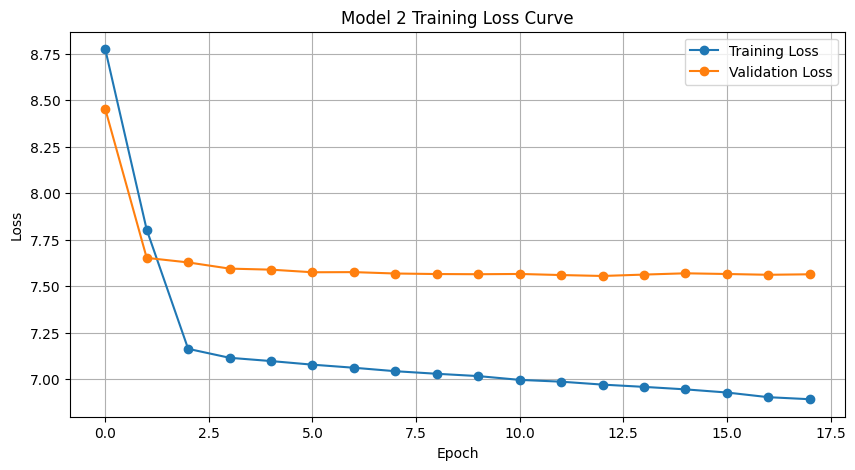

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(trainLosses, label="Training Loss", marker="o")
plt.plot(valLosses, label="Validation Loss", marker="o")
plt.title("Model 2 Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [11]:
import pandas as pd

# ================== Load Model 1 Checkpoint ==================
MODEL1_CHECKPOINT = Path("../../results/best_basic.pt")

checkpoint1 = torch.load(MODEL1_CHECKPOINT, map_location=DEVICE)
model1_token2idx = checkpoint1["tokenToIdx"]
model1_idx2token = {v: k for k, v in model1_token2idx.items()}


class BasicDecoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, n_layers, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.lstm = nn.LSTM(
            embed_dim,
            hidden_dim,
            n_layers,
            batch_first=True,
            dropout=dropout if n_layers > 1 else 0,
        )
        self.fc = nn.Linear(hidden_dim, vocab_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, token, hidden):
        embedded = self.dropout(self.embedding(token.unsqueeze(1)))
        output, hidden = self.lstm(embedded, hidden)
        logits = self.fc(output.squeeze(1))
        return logits, hidden


model1_encoder = Encoder(
    len(model1_token2idx),
    checkpoint1["embed_dim"],
    checkpoint1["hidden_dim"],
    checkpoint1["n_layers"],
    checkpoint1["dropout"],
).to(DEVICE)
model1_decoder = BasicDecoder(
    len(model1_token2idx),
    checkpoint1["embed_dim"],
    checkpoint1["hidden_dim"],
    checkpoint1["n_layers"],
    checkpoint1["dropout"],
).to(DEVICE)

model1_encoder.load_state_dict(
    {
        k.replace("encoder.", ""): v
        for k, v in checkpoint1["model_state"].items()
        if k.startswith("encoder.")
    }
)
model1_decoder.load_state_dict(
    {
        k.replace("decoder.", ""): v
        for k, v in checkpoint1["model_state"].items()
        if k.startswith("decoder.")
    }
)
model1_encoder.eval()
model1_decoder.eval()


@torch.no_grad()
def generate_model1_greedy(question_ids, max_len=30):
    src = torch.tensor([question_ids], device=DEVICE)
    src_lens = torch.tensor([len(question_ids)], device=DEVICE)

    _, hidden = model1_encoder(src, src_lens)
    token = torch.tensor([SOS_IDX], device=DEVICE)

    result = []
    for _ in range(max_len):
        logits, hidden = model1_decoder(token, hidden)
        token = logits.argmax(dim=-1)
        if token.item() == EOS_IDX:
            break
        result.append(model1_idx2token.get(token.item(), "<UNK>"))

    return result


@torch.no_grad()
def generate_model2_greedy(model, question_ids, max_len=30):
    model.eval()
    src = torch.tensor([question_ids], device=DEVICE)
    src_lens = torch.tensor([len(question_ids)], device=DEVICE)

    encoder_outputs, hidden = model.encoder(src, src_lens)
    token = torch.tensor([SOS_IDX], device=DEVICE)

    result = []
    for _ in range(max_len):
        logits, hidden = model.decoder(token, hidden, encoder_outputs)
        token = logits.argmax(dim=-1)
        if token.item() == EOS_IDX:
            break
        result.append(idx2token.get(token.item(), "<UNK>"))

    return result


# ================== Model 2 Results ==================
model2_examples = samples

# ================== Calculate BLEU ==================
smoothie = SmoothingFunction().method4
data = []

for ex in model2_examples[:6]:
    q_text = ex["Question"]
    real_answer = ex["Real Answer"]

    q_tokens = q_text.split()
    q_ids_model1 = (
        [SOS_IDX] + [model1_token2idx.get(t, UNK_IDX) for t in q_tokens] + [EOS_IDX]
    )
    q_ids_model2 = [SOS_IDX] + [token2idx.get(t, UNK_IDX) for t in q_tokens] + [EOS_IDX]

    model1_pred_tokens = generate_model1_greedy(q_ids_model1)
    model2_pred_tokens = generate_model2_greedy(model2, q_ids_model2)

    model1_pred = " ".join(model1_pred_tokens)
    model2_pred = " ".join(model2_pred_tokens)

    model1_bleu = sentence_bleu(
        [real_answer.split()], model1_pred.split(), smoothing_function=smoothie
    )
    model2_bleu = sentence_bleu(
        [real_answer.split()], model2_pred.split(), smoothing_function=smoothie
    )

    data.append(
        {
            "Question": q_text,
            "Real Answer": real_answer,
            "Model 1 (No Attention)": model1_pred,
            "Model 2 (Luong Attention - Greedy)": model2_pred,
            "Model 1 BLEU": round(model1_bleu, 4),
            "Model 2 BLEU": round(model2_bleu, 4),
        }
    )

df = pd.DataFrame(data)
print("✅ Model 1 vs Model 2 Comparison Table (with BLEU)")
display(df)

# Optional: save to CSV for report
df.to_csv("../../results/model1_vs_model2_comparison.csv", index=False)
print("✅ Table saved as model1_vs_model2_comparison.csv")

✅ Model 1 vs Model 2 Comparison Table (with BLEU)


,Question,Real Answer,Model 1 (No Attention),Model 2 (Luong Attention - Greedy),Model 1 BLEU,Model 2 BLEU
0,how african americans were immigrated to the us,as such african immigrants are to be distingui...,the is is a is a of the of the of the of the o...,the is a is a is a of the of the of the of the...,0.0093,0.0098
1,how a water pump works,pumps operate by some mechanism typically reci...,the is is a is a of the of the of the of the,the is a is a of the of the of the of the of the,0.0115,0.0119
2,how old was sue lyon when she made lolita,the actress who played lolita sue lyon was fou...,the is is a is a of the of the of the of the o...,the is a is a is a of the of the of the of the...,0.0187,0.0197
3,what does s h i e l d stand for,the acronym originally stood for supreme headq...,the is is a is a is a of the of the of the of ...,the is the is a is a of the of the of the of t...,0.0142,0.0149
4,what day is st patricks day,saint patrick 's day or the feast of saint pat...,the is is a is a of the of the of the of the o...,the is a is a of the of of the of the of the,0.0308,0.0274
5,how many books are included in the protestant ...,christian bibles range from the sixty six book...,the is is a is a of the of the of the of the o...,the is the is a is a of the of the of the of t...,0.0366,0.0357


✅ Table saved as model1_vs_model2_comparison.csv


---

## Results and interpretation

### What the numbers show

Validation loss improves quickly in the first few epochs (8.41 to 7.56) and then plateaus, with the best checkpoint at epoch 11 (val loss 7.5616, PPL 1922.97). Early stopping triggers at epoch 16 after five epochs without improvement. Training loss keeps decreasing to 6.95 by epoch 15, so the train--validation gap widens as optimization proceeds, indicating continued memorization without better generalization.

The average BLEU-1 from beam search evaluation is 0.0185. This is slightly above zero but still extremely low, which signals that most generated tokens do not overlap with the reference answers even after using a search strategy that reduces repetition.

### What the inference output shows

The sampled predictions are still dominated by high-frequency function words ("the", "is", "of"). Compared with Model 1, the Luong attention model sometimes produces marginally higher BLEU on a few examples (e.g., 0.0231 vs 0.0187), but the gains are inconsistent and often negative. Across all examples, both models remain stuck in short, repetitive loops and do not generate content words tied to the question.

### Why attention helps only marginally here

**Data scarcity.** Attention provides a stronger conditioning signal by letting the decoder attend to encoder time steps, but with only 728 training pairs the model still sees too few question--answer mappings to learn reliable alignments. The decoder therefore falls back to the marginal token distribution.

**Exposure bias remains.** Even with attention, the decoder is trained under teacher forcing and must generate autoregressively at inference. Once a frequent token appears, the next-step distribution is biased toward another frequent token, leading to repetition.

**Search strategy is not a fix.** Beam search reduces some repetition compared to greedy decoding, but it cannot create missing content. It only explores the same low-information token space more thoroughly.

### Takeaway

Luong attention reduces the encoder bottleneck, but on this small dataset it does not materially change the model behavior. The results still look like mode collapse toward generic function words, and BLEU remains near zero. Substantial gains would likely require more data, subword tokenization, or pretraining rather than architectural tweaks alone.